In [1]:
# 1. Install dependencies
!pip install -U torch torchvision torchaudio
!pip install -U opencv-python-headless
!pip install -U git+https://github.com/facebookresearch/detectron2.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 132.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [2]:
!curl -L "https://app.roboflow.com/ds/vmqljNA5Lg?key=EfUNIyywbX" > roboflow.zip
!unzip roboflow.zip
!rm roboflow.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   901  100   901    0     0   2693      0 --:--:-- --:--:-- --:--:--  2697
100  136M  100  136M    0     0  33.8M      0  0:00:04  0:00:04 --:--:-- 40.3M
Archive:  roboflow.zip
  inflating: README.dataset.txt      
  inflating: README.roboflow.txt     
   creating: test/
 extracting: test/045e20b0592d4fb61d5a5f4b8a8ba6bf_jpg.rf.c9bbadbdb6c72bfa3eb49356a8584510.jpg  
 extracting: test/135960_main__jpg.rf.d1afbb7af68a903068068c4aef0eaebd.jpg  
 extracting: test/1576647861859_3_jpg.rf.a5b4897a4d84c660deccaebf8c0c9113.jpg  
 extracting: test/1588753551723_7169ryxt2v4_png_jpg.rf.ef85bb01bee9c55c7099e8e1b57c669a.jpg  
 extracting: test/1590122676583_omcucvx5g5o_jpg.rf.13ea539f2aaca0d914189727d6bea281.jpg  
 extracting: test/1605496729823_ci0o5aow9x_jpg.rf.be63d2c2b1cca21b7a6cd29948a2c70d.jpg  
 extracting: test/1606698821244_ztadcdt

In [3]:
# 2. Imports and dataset registration
import os
from detectron2.data.datasets import register_coco_instances
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.engine import HookBase
import csv

# Change this to your dataset root folder
dataset_root = "/content"

# Register datasets (images + annotations are in the same folder)
register_coco_instances("custom_train", {}, f"{dataset_root}/train/_annotations.coco.json", f"{dataset_root}/train")
register_coco_instances("custom_val", {}, f"{dataset_root}/valid/_annotations.coco.json", f"{dataset_root}/valid")
register_coco_instances("custom_test", {}, f"{dataset_root}/test/_annotations.coco.json", f"{dataset_root}/test")

# 3. Configure model and training settings
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))

cfg.DATASETS.TRAIN = ("custom_train",)
cfg.DATASETS.TEST = ("custom_val",)
cfg.DATALOADER.NUM_WORKERS = 2

# Load pre-trained weights
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")

cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 5000
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 52  # Number of classes in your dataset

cfg.OUTPUT_DIR = "./output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)



class LossLogger(HookBase):
    def __init__(self, output_path="loss_log.csv"):
        self.output_path = output_path
        self.fields = ["iteration", "total_loss", "loss_cls", "loss_box_reg", "loss_rpn_cls", "loss_rpn_loc"]

        with open(self.output_path, 'w') as f:
            writer = csv.writer(f)
            writer.writerow(self.fields)

    def after_step(self):
        loss_dict = {k: float(self.trainer.storage.history(k).latest()) for k in self.fields[1:]}
        loss_dict["iteration"] = self.trainer.iter

        with open(self.output_path, 'a') as f:
            writer = csv.writer(f)
            writer.writerow([loss_dict[k] for k in self.fields])



# 4. Train the model
trainer = DefaultTrainer(cfg)
trainer.register_hooks([LossLogger()])
trainer.train()



[06/03 07:33:50 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

/usr/local/lib/python3.11/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[06/03 07:33:58 d2.utils.events]:  eta: 0:22:40  iter: 19  total_loss: 123.2  loss_cls: 91.1  loss_box_reg: 20.61  loss_rpn_cls: 2.299  loss_rpn_loc: 2.515    time: 0.2799  last_time: 0.2702  data_time: 0.0149  last_data_time: 0.0044   lr: 4.9953e-06  max_mem: 1742M
[06/03 07:34:14 d2.utils.events]:  eta: 0:23:21  iter: 39  total_loss: 9.846  loss_cls: 3.499  loss_box_reg: 1.682  loss_rpn_cls: 0.3414  loss_rpn_loc: 0.3774    time: 0.3046  last_time: 0.4293  data_time: 0.0155  last_data_time: 0.0248   lr: 9.9902e-06  max_mem: 1742M
[06/03 07:34:20 d2.utils.events]:  eta: 0:23:12  iter: 59  total_loss: 3.9  loss_cls: 1.877  loss_box_reg: 0.9907  loss_rpn_cls: 0.1018  loss_rpn_loc: 0.1158    time: 0.2973  last_time: 0.2825  data_time: 0.0085  last_data_time: 0.0045   lr: 1.4985e-05  max_mem: 1742M
[06/03 07:34:26 d2.utils.events]:  eta: 0:23:30  iter: 79  total_loss: 1.46  loss_cls: 0.6735  loss_box_reg: 0.422  loss_rpn_cls: 0.04491  loss_rpn_loc: 0.06357    time: 0.2965  last_time: 0.286

In [4]:
# 5. Evaluate on the test set
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

evaluator = COCOEvaluator("custom_test", cfg, False, output_dir=cfg.OUTPUT_DIR)
test_loader = build_detection_test_loader(cfg, "custom_test")
inference_on_dataset(trainer.model, test_loader, evaluator)


WARNING [06/03 07:59:51 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.
WARNING [06/03 07:59:51 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[06/03 07:59:51 d2.data.datasets.coco]: Loaded 252 images in COCO format from /content/test/_annotations.coco.json
[06/03 07:59:51 d2.data.build]: Distribution of instances among all 52 categories:
|   category    | #instances   |   category    | #instances   |   category    | #instances   |
|:-------------:|:-------------|:-------------:|:-------------|:-------------:|:-------------|
| dumbbells-p.. | 0            | Gym Equipment | 26           | Kitchen Item  | 19           |
|    Tshirt     | 31           |  can-opener   | 1            | chopping-bo.. | 2            |
| circular-fo.. | 0            |  cooking-pot  | 0            | cooking-str.. | 0            |
|  dish-cover   | 0

OrderedDict([('bbox',
              {'AP': 0.6636919183361016,
               'AP50': 2.3668366322227588,
               'AP75': 0.20380127604837903,
               'APs': nan,
               'APm': 0.0,
               'APl': 0.6786794120160078,
               'AP-dumbbells-pants-objects': nan,
               'AP-Gym Equipment': 0.16427101992813553,
               'AP-Kitchen Item': 2.2285125949188966,
               'AP-Tshirt': 0.24634290432706635,
               'AP-can-opener': 0.0,
               'AP-chopping-board': 0.0,
               'AP-circular-food-container': nan,
               'AP-cooking-pot': nan,
               'AP-cooking-strainer': nan,
               'AP-dish-cover': nan,
               'AP-drinking-glass': 0.0,
               'AP-dumbbells': 4.871333908129342,
               'AP-eggbeater': 0.0,
               'AP-electric-kettle': nan,
               'AP-food-bowl': 0.0,
               'AP-food-jar': nan,
               'AP-food-picker': 0.0,
               'AP-fo

In [5]:
import pandas as pd
import plotly.graph_objects as go

# Load the data
df = pd.read_csv("loss_log.csv")

# Create a figure
fig = go.Figure()

# Add traces (lines) for each column except the first one (iteration column)
for col in df.columns[1:]:
    fig.add_trace(go.Scatter(x=df["iteration"], y=df[col], mode='lines', name=col))

# Update layout for better visualization
fig.update_layout(
    title="Training Losses",
    xaxis_title="Iteration",
    yaxis_title="Loss",
    template="plotly_dark",  # Optional: use a dark theme for the plot
    hovermode="closest",     # Show values on hover
)

# Show the plot
fig.show()


In [6]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load the data
df = pd.read_csv("loss_log.csv")

# Create subplots (one per loss type)
fig = make_subplots(
    rows=len(df.columns) - 1,  # Number of loss types (ignoring the iteration column)
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    subplot_titles=df.columns[1:],  # Loss types as subplot titles
)

# Add traces for each loss type to its respective subplot
for i, col in enumerate(df.columns[1:], start=1):  # Skipping the first column (iteration)
    fig.add_trace(
        go.Scatter(x=df["iteration"], y=df[col], mode='lines', name=col),
        row=i, col=1
    )

# Update layout for better visualization
fig.update_layout(
    title="Training Losses",
    xaxis_title="Iteration",
    template="plotly_dark",  # Optional: use a dark theme for the plot
    hovermode="closest",     # Show values on hover
)

# Show the plot
fig.show()


In [7]:
import torch

# Assuming training has finished and the best model is saved
# Save model weights
model_weights_path = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
trainer.checkpointer.save("model_final")
print(f"Model saved to {model_weights_path}")


Model saved to ./output/model_final.pth


In [8]:
from detectron2.engine import DefaultPredictor

# Load the config (same as the one used for training)
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("custom_train",)
cfg.DATASETS.TEST = ("custom_val",)

# IMPORTANT: You must specify NUM_CLASSES again
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 52

cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  # Path to the saved model checkpoint
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.4  # Set score threshold for predictions

# Create predictor
predictor = DefaultPredictor(cfg)


[06/03 08:00:19 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...


Predicted boxes: Boxes(tensor([[205.6449,  79.3221, 592.9371, 522.4348],
        [ 81.4342,  61.4567, 422.0604, 544.1179]], device='cuda:0'))
Predicted classes: tensor([11, 11], device='cuda:0')
Predicted scores: tensor([0.6912, 0.6163], device='cuda:0')
There are predictions.


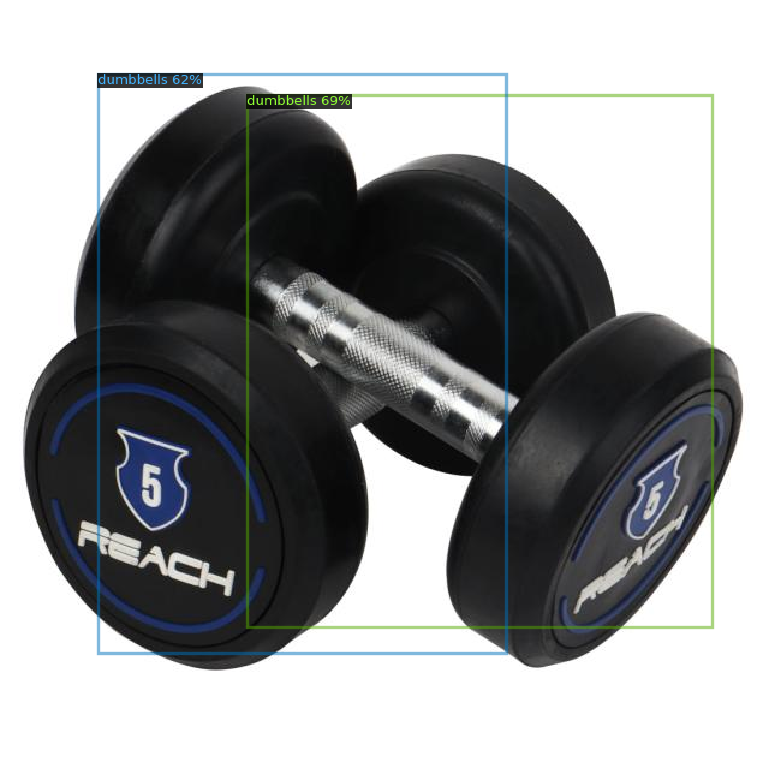

In [14]:
import cv2
from google.colab.patches import cv2_imshow

# Load an image for testing
image = cv2.imread("/content/test/Reach-Rubber_Dumbbells-5kg-1-Aug_jpg.rf.d3b9cd273bc05bf982e89c54673ace70.jpg")  # Provide the path to your test image

# Make predictions
outputs = predictor(image)

# Get the predictions (e.g., boxes, labels, and scores)
pred_boxes = outputs["instances"].pred_boxes
pred_classes = outputs["instances"].pred_classes
pred_scores = outputs["instances"].scores

# Debug: Print prediction details
print("Predicted boxes:", pred_boxes)
print("Predicted classes:", pred_classes)
print("Predicted scores:", pred_scores)

# Check if there are any predictions with a score above threshold
if len(pred_boxes) > 0:
    print("There are predictions.")
else:
    print("No predictions detected.")

# Optionally, you can visualize the results (e.g., display boxes on the image)
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog

metadata = MetadataCatalog.get("custom_train")  # Using your custom dataset
visualizer = Visualizer(image[:, :, ::-1], metadata=metadata, scale=1.2)
output_image = visualizer.draw_instance_predictions(outputs["instances"].to("cpu"))

# Save or display the output image
cv2_imshow(output_image.get_image()[:, :, ::-1])  # Display the image in Colab


In [15]:
import torch
import cv2
import os
import json
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.data.datasets import register_coco_instances
import numpy as np
from google.colab.patches import cv2_imshow

# Paths
dataset_root = "/content"
model_weights_path = "./output/model_final.pth"
video_input_path = "/content/test video.mp4"
video_output_path = "annotated_video.mp4"
stats_output_path = "./output/detection_stats.json"  # Path to save detection statistics

# Register datasets to access metadata (needed for class names)
if "custom_train" not in DatasetCatalog:
    register_coco_instances("custom_train", {}, f"{dataset_root}/train/_annotations.coco.json", f"{dataset_root}/train")
if "custom_val" not in DatasetCatalog:
    register_coco_instances("custom_val", {}, f"{dataset_root}/valid/_annotations.coco.json", f"{dataset_root}/valid")
if "custom_test" not in DatasetCatalog:
    register_coco_instances("custom_test", {}, f"{dataset_root}/test/_annotations.coco.json", f"{dataset_root}/test")

# Load model configuration
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("custom_train",)
cfg.DATASETS.TEST = ("custom_val",)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 52  # Number of classes in your dataset
cfg.MODEL.WEIGHTS = model_weights_path  # Path to trained model weights
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.4  # Confidence threshold for predictions
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # Use GPU if available

# Create predictor
predictor = DefaultPredictor(cfg)

# Get metadata for visualization and class names
metadata = MetadataCatalog.get("custom_train")
class_names = metadata.thing_classes  # List of class names

# Open the input video
cap = cv2.VideoCapture(video_input_path)
if not cap.isOpened():
    raise ValueError(f"Could not open video file: {video_input_path}")

# Get video properties
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Initialize video writer for output
fourcc = cv2.VideoWriter_fourcc(*"mp4v")  # Codec for MP4
out = cv2.VideoWriter(video_output_path, fourcc, fps, (frame_width, frame_height))

# Initialize detection statistics
detection_stats = {
    class_name: {"count": 0, "scores": []} for class_name in class_names
}

print(f"Processing video: {video_input_path}")
print(f"Output will be saved to: {video_output_path}")
print(f"Frame size: {frame_width}x{frame_height}, FPS: {fps}, Total frames: {total_frames}")

# Process video frame by frame
frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Make predictions
    outputs = predictor(frame)
    instances = outputs["instances"].to("cpu")

    # Collect detection statistics
    if instances.has("pred_classes") and len(instances) > 0:
        pred_classes = instances.pred_classes.numpy()
        pred_scores = instances.scores.numpy()
        for class_id, score in zip(pred_classes, pred_scores):
            class_name = class_names[class_id]
            detection_stats[class_name]["count"] += 1
            detection_stats[class_name]["scores"].append(float(score))

    # Visualize predictions
    visualizer = Visualizer(frame[:, :, ::-1], metadata=metadata, scale=1.0)  # Convert BGR to RGB
    annotated_frame = visualizer.draw_instance_predictions(instances)
    annotated_frame = annotated_frame.get_image()[:, :, ::-1]  # Convert back to BGR for OpenCV

    # Write the annotated frame to the output video
    out.write(annotated_frame)

    # Optionally display the frame (for debugging in Colab)
    if frame_count % 100 == 0:  # Display every 100th frame
        print(f"Processed frame {frame_count}/{total_frames}")

    frame_count += 1

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()

print(f"Video processing complete. Annotated video saved to: {video_output_path}")

# Compute average confidence scores and prepare statistics
stats_summary = {}
for class_name, data in detection_stats.items():
    count = data["count"]
    scores = data["scores"]
    avg_score = np.mean(scores) if scores else 0.0
    stats_summary[class_name] = {
        "count": count,
        "average_confidence": avg_score
    }

# Print detection statistics
print("\nDetection Statistics:")
for class_name, stats in stats_summary.items():
    if stats["count"] > 0:
        print(f"Class: {class_name}, Count: {stats['count']}, Avg Confidence: {stats['average_confidence']:.4f}")

# Save detection statistics to JSON
os.makedirs(os.path.dirname(stats_output_path), exist_ok=True)
with open(stats_output_path, "w") as f:
    json.dump(stats_summary, f, indent=2)
print(f"Detection statistics saved to: {stats_output_path}")


[06/03 08:02:19 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...


ValueError: Could not open video file: /content/test video.mp4

# RetineNet

In [16]:
import os
import csv
import torch
import numpy as np
from detectron2.data.datasets import register_coco_instances
from detectron2.engine import DefaultTrainer, HookBase
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Dataset root folder
dataset_root = "/content"

# Register datasets
register_coco_instances("custom_train", {}, f"{dataset_root}/train/_annotations.coco.json", f"{dataset_root}/train")
register_coco_instances("custom_val", {}, f"{dataset_root}/valid/_annotations.coco.json", f"{dataset_root}/valid")
register_coco_instances("custom_test", {}, f"{dataset_root}/test/_annotations.coco.json", f"{dataset_root}/test")

# Configure model and training settings
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/retinanet_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("custom_train",)
cfg.DATASETS.TEST = ("custom_val",)
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/retinanet_R_50_FPN_3x.yaml")
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.0001  # Lower learning rate for stability
cfg.SOLVER.MAX_ITER = 1000
cfg.SOLVER.STEPS = []  # Remove invalid steps
cfg.SOLVER.CLIP_GRADIENTS.ENABLED = True  # Enable gradient clipping
cfg.SOLVER.CLIP_GRADIENTS.CLIP_VALUE = 1.0  # Clip gradients to prevent explosion
cfg.MODEL.RETINANET.NUM_CLASSES = 52  # Number of classes in your dataset
cfg.OUTPUT_DIR = "./output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# Custom Trainer to handle NaN losses
class CustomTrainer(DefaultTrainer):
    def run_step(self):
        try:
            super().run_step()
        except FloatingPointError as e:
            print(f"Caught FloatingPointError: {e}")
            for name, param in self.model.named_parameters():
                if param.grad is not None and not torch.isfinite(param.grad).all():
                    print(f"Non-finite gradient in {name}")
                    param.grad = torch.where(torch.isfinite(param.grad), param.grad, torch.zeros_like(param.grad))
            self.optimizer.step()
            self.optimizer.zero_grad()

class LossLogger(HookBase):
    def __init__(self, output_path="loss_log.csv"):
        self.output_path = output_path
        self.fields = ["iteration", "total_loss", "loss_cls", "loss_box_reg"]  # RetinaNet losses

        with open(self.output_path, 'w') as f:
            writer = csv.writer(f)
            writer.writerow(self.fields)

    def after_step(self):
        loss_dict = {}
        for k in self.fields[1:]:
            value = self.trainer.storage.history(k).latest()
            loss_dict[k] = float(value) if np.isfinite(value) else 0.0  # Handle NaN
        loss_dict["iteration"] = self.trainer.iter

        with open(self.output_path, 'a') as f:
            writer = csv.writer(f)
            writer.writerow([loss_dict[k] for k in self.fields])

# Train the model
trainer = CustomTrainer(cfg)
trainer.register_hooks([LossLogger()])
trainer.train()


[06/03 08:02:34 d2.engine.defaults]: Model:
RetinaNet(
  (backbone): FPN(
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelP6P7(
      (p6): Conv2d(2048, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (p7): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res2)

In [17]:
# Evaluate on the test set
evaluator = COCOEvaluator("custom_test", cfg, False, output_dir=cfg.OUTPUT_DIR)
test_loader = build_detection_test_loader(cfg, "custom_test")
inference_on_dataset(trainer.model, test_loader, evaluator)


WARNING [06/03 08:08:22 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.
WARNING [06/03 08:08:22 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[06/03 08:08:22 d2.data.datasets.coco]: Loaded 252 images in COCO format from /content/test/_annotations.coco.json
[06/03 08:08:22 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[06/03 08:08:22 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[06/03 08:08:22 d2.data.common]: Serializing 252 elements to byte tensors and concatenating them all ...
[06/03 08:08:22 d2.data.common]: Serialized dataset takes 0.08 MiB
[06/03 08:08:22 d2.evaluation.evaluator]: Start inference on 252 batches
[06/03 08:08:24 d2.evaluation.evalu

OrderedDict([('bbox',
              {'AP': 0.06150530444928178,
               'AP50': 0.25572653552108054,
               'AP75': 0.02696955571822892,
               'APs': nan,
               'APm': 0.0,
               'APl': 0.06267161678004878,
               'AP-dumbbells-pants-objects': nan,
               'AP-Gym Equipment': 0.003429426251075391,
               'AP-Kitchen Item': 0.41630588468192403,
               'AP-Tshirt': 0.004402330178414189,
               'AP-can-opener': 0.0,
               'AP-chopping-board': 0.0,
               'AP-circular-food-container': nan,
               'AP-cooking-pot': nan,
               'AP-cooking-strainer': nan,
               'AP-dish-cover': nan,
               'AP-drinking-glass': 0.0,
               'AP-dumbbells': 0.45445350897532577,
               'AP-eggbeater': 0.0,
               'AP-electric-kettle': nan,
               'AP-food-bowl': 0.0,
               'AP-food-jar': nan,
               'AP-food-picker': 0.0,
             

In [18]:
# Visualize training losses
df = pd.read_csv("loss_log.csv")
fig = make_subplots(
    rows=len(df.columns) - 1,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    subplot_titles=df.columns[1:],
)
for i, col in enumerate(df.columns[1:], start=1):
    fig.add_trace(
        go.Scatter(x=df["iteration"], y=df[col], mode='lines', name=col),
        row=i, col=1
    )
fig.update_layout(
    title="Training Losses",
    xaxis_title="Iteration",
    template="plotly_dark",
    hovermode="closest",
)
fig.show()


In [19]:
# Save model weights
model_weights_path = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
trainer.checkpointer.save("model_final")
print(f"Model saved to {model_weights_path}")


Model saved to ./output/model_final.pth


In [20]:
from detectron2.engine import DefaultPredictor

# Load the config (same as the one used for training)
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/retinanet_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("custom_train",)
cfg.DATASETS.TEST = ("custom_val",)

# IMPORTANT: You must specify NUM_CLASSES again
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 52

cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  # Path to the saved model checkpoint
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.4  # Set score threshold for predictions

# Create predictor
predictor = DefaultPredictor(cfg)


[06/03 08:08:46 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...


head.cls_score.{bias, weight}


In [21]:
import torch
import cv2
import os
import json
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.data.datasets import register_coco_instances
import numpy as np
from google.colab.patches import cv2_imshow

# Paths
dataset_root = "/content"
model_weights_path = "./output/model_final.pth"
video_input_path = "/content/test video.mp4"
video_output_path = "annotated_video.mp4"
stats_output_path = "./output/detection_stats.json"

# Register datasets to access metadata
if "custom_train" not in DatasetCatalog:
    register_coco_instances("custom_train", {}, f"{dataset_root}/train/_annotations.coco.json", f"{dataset_root}/train")
if "custom_val" not in DatasetCatalog:
    register_coco_instances("custom_val", {}, f"{dataset_root}/valid/_annotations.coco.json", f"{dataset_root}/valid")
if "custom_test" not in DatasetCatalog:
    register_coco_instances("custom_test", {}, f"{dataset_root}/test/_annotations.coco.json", f"{dataset_root}/test")

# Load model configuration
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/retinanet_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("custom_train",)
cfg.DATASETS.TEST = ("custom_val",)
cfg.MODEL.RETINANET.NUM_CLASSES = 52
cfg.MODEL.WEIGHTS = model_weights_path
cfg.MODEL.RETINANET.SCORE_THRESH_TEST = 0.4
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Create predictor
predictor = DefaultPredictor(cfg)

# Get metadata for visualization and class names
metadata = MetadataCatalog.get("custom_train")
class_names = metadata.thing_classes

# Open the input video
cap = cv2.VideoCapture(video_input_path)
if not cap.isOpened():
    raise ValueError(f"Could not open video file: {video_input_path}")

# Get video properties
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Initialize video writer for output
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(video_output_path, fourcc, fps, (frame_width, frame_height))

# Initialize detection statistics
detection_stats = {
    class_name: {"count": 0, "scores": []} for class_name in class_names
}

print(f"Processing video: {video_input_path}")
print(f"Output will be saved to: {video_output_path}")
print(f"Frame size: {frame_width}x{frame_height}, FPS: {fps}, Total frames: {total_frames}")

# Process video frame by frame
frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Make predictions
    outputs = predictor(frame)
    instances = outputs["instances"].to("cpu")

    # Collect detection statistics
    if instances.has("pred_classes") and len(instances) > 0:
        pred_classes = instances.pred_classes.numpy()
        pred_scores = instances.scores.numpy()
        for class_id, score in zip(pred_classes, pred_scores):
            class_name = class_names[class_id]
            detection_stats[class_name]["count"] += 1
            detection_stats[class_name]["scores"].append(float(score))

    # Visualize predictions
    visualizer = Visualizer(frame[:, :, ::-1], metadata=metadata, scale=1.0)
    annotated_frame = visualizer.draw_instance_predictions(instances)
    annotated_frame = annotated_frame.get_image()[:, :, ::-1]

    # Write the annotated frame to the output video
    out.write(annotated_frame)

    # Optionally display the frame
    if frame_count % 100 == 0:
        print(f"Processed frame {frame_count}/{total_frames}")

    frame_count += 1

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()

print(f"Video processing complete. Annotated video saved to: {video_output_path}")

# Compute average confidence scores and prepare statistics
stats_summary = {}
for class_name, data in detection_stats.items():
    count = data["count"]
    scores = data["scores"]
    avg_score = np.mean(scores) if scores else 0.0
    stats_summary[class_name] = {
        "count": count,
        "average_confidence": avg_score
    }

# Print detection statistics
print("\nDetection Statistics:")
for class_name, stats in stats_summary.items():
    if stats["count"] > 0:
        print(f"Class: {class_name}, Count: {stats['count']}, Avg Confidence: {stats['average_confidence']:.4f}")

# Save detection statistics to JSON
os.makedirs(os.path.dirname(stats_output_path), exist_ok=True)
with open(stats_output_path, "w") as f:
    json.dump(stats_summary, f, indent=2)
print(f"Detection statistics saved to: {stats_output_path}")


[06/03 08:08:47 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...


ValueError: Could not open video file: /content/test video.mp4

In [22]:
import os
import json
import time

import torch
import numpy as np
import pandas as pd
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.data.datasets import register_coco_instances
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
from detectron2.utils.logger import setup_logger

setup_logger()


<Logger detectron2 (DEBUG)>

In [23]:
def register_datasets(dataset_root="/content"):
    for split in ["train", "valid", "test"]:
        json_file = f"{dataset_root}/{split}/_annotations.coco.json"

        # Load category information
        with open(json_file) as f:
            coco_data = json.load(f)
            categories = coco_data["categories"]

        # Create ID mapping dictionary
        id_map = {c["id"]: i for i, c in enumerate(categories)}

        # Register dataset with metadata
        MetadataCatalog.get(f"custom_{split}").set(
            thing_classes=[c["name"] for c in categories],
            thing_dataset_id_to_contiguous_id=id_map
        )

        register_coco_instances(
            f"custom_{split}",
            {},
            json_file,
            f"{dataset_root}/{split}"
        )

register_datasets()


In [24]:
metadata = MetadataCatalog.get("custom_train")
print("Class mapping:", metadata.thing_dataset_id_to_contiguous_id)
print("Class names:", metadata.thing_classes)


Class mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33, 34: 34, 35: 35, 36: 36, 37: 37, 38: 38, 39: 39, 40: 40, 41: 41, 42: 42, 43: 43, 44: 44, 45: 45, 46: 46, 47: 47, 48: 48, 49: 49, 50: 50, 51: 51}
Class names: ['dumbbells-pants-objects', 'Gym Equipment', 'Kitchen Item', 'Tshirt', 'can-opener', 'chopping-board', 'circular-food-container', 'cooking-pot', 'cooking-strainer', 'dish-cover', 'drinking-glass', 'dumbbells', 'eggbeater', 'electric-kettle', 'food-bowl', 'food-jar', 'food-picker', 'food-tray', 'frying-pan', 'grater', 'jacket', 'kettle', 'kitchen-knife', 'kitchen-turner', 'ladle', 'long-dress', 'long-skirt', 'metal-fork', 'metal-spoon', 'midi-dress', 'midi-skirt', 'mini plate', 'mug', 'objects', 'pants', 'pitcher', 'plastic-fork', 'plastic-spoon', 'plate', 'potholder', 

In [25]:
import os # Get the current working directory
HOME = os.getcwd() # Get the current working directory
print(HOME) # Print the current working directory


/content


In [26]:
# 3. Model Configuration and Training Class
class CustomTrainer(DefaultTrainer):
    def run_step(self):
        """Handle NaN gradients"""
        try:
            super().run_step()
        except FloatingPointError as e:
            print(f"Caught FloatingPointError: {e}")
            for name, param in self.model.named_parameters():
                if param.grad is not None and not torch.isfinite(param.grad).all():
                    print(f"Non-finite gradient in {name}")
                    param.grad = torch.where(torch.isfinite(param.grad),
                                          param.grad,
                                          torch.zeros_like(param.grad))
            self.optimizer.step()
            self.optimizer.zero_grad()

class ModelTrainer:
    def __init__(self, model_name, num_classes=52):
        self.model_name = model_name
        self.num_classes = num_classes
        self.cfg = get_cfg()
        self.metrics = {}
        self.yolo_dataset_path = None  # Store YOLO dataset path

        # Model configuration
        if "YOLO" in model_name:
            self.setup_yolo()
        else:
            self.setup_detectron2_model()

    def setup_detectron2_model(self):
        """Configure Detectron2 model with stability enhancements"""
        config_file = {
            "Faster R-CNN": "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml",
            "RetinaNet": "COCO-Detection/retinanet_R_50_FPN_3x.yaml"
        }[self.model_name]

        self.cfg.merge_from_file(model_zoo.get_config_file(config_file))
        self.cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(config_file)
        self.cfg.MODEL.ROI_HEADS.NUM_CLASSES = self.num_classes
        self.cfg.DATASETS.TRAIN = ("custom_train",)
        self.cfg.DATASETS.TEST = ("custom_test",)
        self.cfg.DATALOADER.NUM_WORKERS = 2
        self.cfg.SOLVER.IMS_PER_BATCH = 2
        self.cfg.SOLVER.BASE_LR = 0.0001
        self.cfg.SOLVER.STEPS = []
        self.cfg.SOLVER.MAX_ITER = 100
        self.cfg.SOLVER.CHECKPOINT_PERIOD = 100
        self.cfg.SOLVER.CLIP_GRADIENTS.ENABLED = True
        self.cfg.SOLVER.CLIP_GRADIENTS.CLIP_VALUE = 1.0
        self.cfg.MODEL.BACKBONE.FREEZE_AT = 2
        self.cfg.SOLVER.PATIENCE = 1000
        self.cfg.OUTPUT_DIR = f"./output/{self.model_name.replace(' ', '_')}"
        os.makedirs(self.cfg.OUTPUT_DIR, exist_ok=True)

    def setup_yolo(self):
        """YOLOv8 specific setup"""
        # Install required package
        !pip install ultralytics==8.2.103 -q
        !pip install roboflow==1.1.48 --quiet

        # Download dataset
        from roboflow import Roboflow
        rf = Roboflow(api_key="UGmDlp3rOig59tfYSH9m")
        project = rf.workspace("alexa-fiverr").project("alexa-tybnf")
        dataset = project.version(1).download("yolov8")
        self.yolo_dataset_path = dataset.location  # Store dataset path

        # Initialize model
        from ultralytics import YOLO
        self.model = YOLO("yolov8s.pt")

    def train(self):
        """Train the model and record metrics"""
        if "YOLO" in self.model_name:
            if not self.yolo_dataset_path:
                raise ValueError("YOLO dataset path not initialized!")

            # YOLOv8 training with correct dataset path
            results = self.model.train(
                data=os.path.join(self.yolo_dataset_path, "data.yaml"),
                epochs=10,
                imgsz=640,
                batch=16,
                name=f"yolov8_train",
                exist_ok=True
            )

            # Map YOLO metrics to COCO-style format
            self.metrics = {
                'AP': results.results_dict.get("metrics/mAP50-95(B)", np.nan),
                'AP50': results.results_dict.get("metrics/mAP50(B)", np.nan),
                'AP75': np.nan,  # YOLO doesn't provide AP75 directly
                'APs': np.nan,
                'APm': np.nan,
                'APl': np.nan,
                'AR': results.results_dict.get("metrics/recall", np.nan)
            }
        else:
            # Detectron2 training
            trainer = CustomTrainer(self.cfg)
            trainer.train()

            # Evaluation
            evaluator = COCOEvaluator("custom_test", self.cfg, False, output_dir=self.cfg.OUTPUT_DIR)
            test_loader = build_detection_test_loader(self.cfg, "custom_test")
            results = inference_on_dataset(trainer.model, test_loader, evaluator)

            # Store COCO metrics
            self.metrics = {
                'AP': results['bbox'].get('AP', np.nan),
                'AP50': results['bbox'].get('AP50', np.nan),
                'AP75': results['bbox'].get('AP75', np.nan),
                'APs': results['bbox'].get('APs', np.nan),
                'APm': results['bbox'].get('APm', np.nan),
                'APl': results['bbox'].get('APl', np.nan),
                'AR': results['bbox'].get('AR@100', np.nan),
            }

    def get_metrics(self):
        return self.metrics


In [27]:
# 4. Model Comparison and Statistical Analysis
class ModelAnalyzer:
    def __init__(self):
        self.models = {}
        self.metrics_df = pd.DataFrame()
        self.stat_tests = {}

    def add_model(self, model_name, metrics):
        """Add model metrics to comparison"""
        self.models[model_name] = metrics
        self.metrics_df = pd.DataFrame.from_dict(self.models, orient='index')

    def visualize_metrics(self):
        """Create interactive comparison plot"""
        fig = go.Figure()
        for metric in self.metrics_df.columns:
            fig.add_trace(go.Bar(
                x=self.metrics_df.index,
                y=self.metrics_df[metric],
                name=metric,
                text=self.metrics_df[metric].round(3),
                textposition='auto'
            ))
        fig.update_layout(
            title='Model Performance Comparison',
            barmode='group',
            xaxis_title='Model',
            yaxis_title='Score',
            template='plotly_white'
        )
        fig.show()

    def perform_statistical_test(self, model1, model2):
        """Perform t-test on model metrics"""
        m1 = np.array(list(self.models[model1].values()))
        m2 = np.array(list(self.models[model2].values()))
        t_stat, p_value = stats.ttest_ind(m1, m2)
        self.stat_tests[f"{model1} vs {model2}"] = (t_stat, p_value)
        print(f"T-test {model1} vs {model2}: t={t_stat:.3f}, p={p_value:.4f}")


In [28]:
# 5. Main Execution

# Train and evaluate models
models_to_train = ['Faster R-CNN', 'RetinaNet', 'YOLOv8']
analyzer = ModelAnalyzer()


### Wandb API Key

220bc6c0012ff7598f423aac11dcdd8a6da4a140

In [29]:
for model_name in models_to_train:
    print(f"\nTraining {model_name}...")
    trainer = ModelTrainer(model_name)
    trainer.train()
    metrics = trainer.get_metrics()
    analyzer.add_model(model_name, metrics)



Training Faster R-CNN...
[06/03 08:09:24 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
  


Training RetinaNet...
[06/03 08:10:28 d2.engine.defaults]: Model:
RetinaNet(
  (backbone): FPN(
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelP6P7(
      (p6): Conv2d(2048, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (p7): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
       


Extracting Dataset Version Zip to Alexa-1 in yolov8:: 100%|██████████| 6522/6522 [00:01<00:00, 5550.01it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 21.5M/21.5M [00:00<00:00, 108MB/s] 


...

  0%|          | 0/161 [00:00<?, ?it/s]Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
      10/10      3.95G     0.7312     0.8457      1.222         18        640: 100%|██████████| 161/161 [00:49<00:00,  3.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 14/14 [00:04<00:00,  2.81it/s]


                   all        432        769      0.592      0.568      0.625      0.472

10 epochs completed in 0.161 hours.
Optimizer stripped from runs/detect/yolov8_train/weights/last.pt, 22.6MB
Optimizer stripped from runs/detect/yolov8_train/weights/best.pt, 22.6MB

Validating runs/detect/yolov8_train/weights/best.pt...
Ultralytics YOLOv8.2.103 🚀 Python-3.11.12 torch-2.7.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,145,321 parameters, 0 gradients, 28.5 GFLOPs


Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CON

                   all        432        769      0.594      0.568      0.625      0.472
         Gym Equipment         10         29      0.488      0.379      0.408      0.216
          Kitchen Item         12         26      0.869      0.769      0.855       0.48
                Tshirt         73         93      0.737      0.796      0.864       0.72
            can-opener          1          1       0.19          1      0.199     0.0597
        chopping-board          1          1      0.271          1      0.995      0.796
circular-food-container          1          1      0.255          1      0.995      0.895
           cooking-pot          3          3      0.902      0.333      0.583      0.483
      cooking-strainer          2          2      0.715        0.5      0.566      0.318
             dumbbells         53        115      0.671      0.757      0.754      0.523
             food-bowl          2          2          0          0      0.105     0.0867
              food-j

lr/pg0,▃▆█▇▆▅▄▃▂▁
lr/pg1,▃▆█▇▆▅▄▃▂▁
lr/pg2,▃▆█▇▆▅▄▃▂▁
metrics/mAP50(B),▁▃▄▄▅▆▇███
metrics/mAP50-95(B),▁▃▃▄▄▆▇█▇█
metrics/precision(B),▇█▄▂▆▁▄▄▃▄
metrics/recall(B),▁▂▃▄▄█▇███
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/box_loss,█▄▄▃▃▂▂▂▁▁


In [30]:
# Visualize comparisons
analyzer.visualize_metrics()


In [32]:
# Generate detailed metrics table
print("\nDetailed Metrics Table:")
print(analyzer.metrics_df.round(3))



Detailed Metrics Table:
                 AP   AP50   AP75  APs  APm    APl  AR
Faster R-CNN  0.018  0.082  0.003  NaN  0.0  0.018 NaN
RetinaNet       NaN    NaN    NaN  NaN  NaN    NaN NaN
YOLOv8        0.472  0.625    NaN  NaN  NaN    NaN NaN


In [33]:
# Save results
analyzer.metrics_df.to_csv('model_comparison.csv')
with open('statistical_tests.json', 'w') as f:
    json.dump(analyzer.stat_tests, f, indent=2)
